# Evaluacion de Modelos de Machine Learning

En este notebook realizamos la evaluacion completa de 10 modelos de clasificacion entrenados con datos preprocesados de pacientes diabeticos.

---

## Objetivo

Evaluar el desempeno de los siguientes modelos:

1. **K-Nearest Neighbors (KNN)**
2. **Naive Bayes**
3. **Regresion Logistica con L1 (Lasso)**
4. **Regresion Logistica con L2 (Ridge)**
5. **Ridge Classifier**
6. **Lasso (LogReg L1-Saga optimizado)**
7. **Arbol de Decision**
8. **Random Forest**
9. **XGBoost**
10. **SVM Lineal**

---

## Metricas de Evaluacion

Para cada modelo presentamos:

- **Matriz de Confusion:** Visualizacion de TP, TN, FP, FN
- **Curva ROC y AUC:** Capacidad de discriminacion del modelo
- **Tabla de Metricas:** Accuracy, Precision, Recall, F1-score, AUC
- **Justificacion de Metrica Principal:** Seleccion de la metrica mas relevante para el problema

---

## Datos

Utilizamos los **datos preprocesados** de `../data/processed/`:
- Ya escalados con StandardScaler
- Ya codificados (One-Hot Encoding)
- Train balanceado con SMOTE
- Sin valores faltantes

In [27]:
# =========================================
# 1. Importar librerias necesarias
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modelos de clasificacion
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Metricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.style.use('default')
sns.set_palette("pastel")

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [ ]:
# =========================================
# 2. Cargar datos preprocesados
# =========================================

print("Cargando datos procesados de '../data/processed/'...\n")

# Cargar datos de entrenamiento (BALANCEADOS con SMOTE)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()

# Cargar datos de validacion (SIN balancear)
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()

# Cargar datos de test (SIN balancear)
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("Datos cargados exitosamente\n")

# Informacion de los datos
print("="*60)
print(" "*15 + "INFORMACION DE LOS DATOS")
print("="*60)
print(f"\nDimensiones:")
print(f"  Train:      {X_train.shape[0]:>7,} muestras × {X_train.shape[1]:>3} features")
print(f"  Validation: {X_val.shape[0]:>7,} muestras × {X_val.shape[1]:>3} features")
print(f"  Test:       {X_test.shape[0]:>7,} muestras × {X_test.shape[1]:>3} features")

print(f"\nBalance de clases (Test - datos reales):")
test_counts = pd.Series(y_test).value_counts()
print(f"  Clase 0: {test_counts[0]:>7,} ({test_counts[0]/len(y_test)*100:>5.1f}%)")
print(f"  Clase 1: {test_counts[1]:>7,} ({test_counts[1]/len(y_test)*100:>5.1f}%)")

print("\n" + "="*60)

# Convertir a arrays de NumPy
X_train_array = X_train.values
X_test_array = X_test.values

Cargando datos procesados de 'data/processed/'...

Datos cargados exitosamente

               INFORMACION DE LOS DATOS

Dimensiones:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

Balance de clases (Test - datos reales):
  Clase 0:   8,230 ( 53.9%)
  Clase 1:   7,035 ( 46.1%)

Datos cargados exitosamente

               INFORMACION DE LOS DATOS

Dimensiones:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

Balance de clases (Test - datos reales):
  Clase 0:   8,230 ( 53.9%)
  Clase 1:   7,035 ( 46.1%)



In [29]:
# =========================================
# 3. Funcion de evaluacion completa
# =========================================

# Lista para almacenar resultados
resultados_evaluacion = []

def evaluar_modelo_completo(nombre, modelo, X_train, y_train, X_test, y_test):
    """
    Evaluamos un modelo con metricas completas y visualizaciones.
    
    Args:
        nombre: Nombre del modelo
        modelo: Instancia del modelo (sin entrenar)
        X_train, y_train: Datos de entrenamiento
        X_test, y_test: Datos de test
    
    Retorna:
        Diccionario con todas las metricas calculadas
    """
    
    print(f"\n{'='*80}")
    print(f"EVALUANDO: {nombre}")
    print(f"{'='*80}")
    
    # 1. ENTRENAMIENTO
    print(f"\nEntrenando modelo...")
    modelo.fit(X_train, y_train)
    print(f"Modelo entrenado correctamente")
    
    # 2. PREDICCIONES
    y_pred = modelo.predict(X_test)
    
    # Obtener probabilidades o scores para ROC
    if hasattr(modelo, 'predict_proba'):
        y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        y_pred_proba = modelo.decision_function(X_test)
    else:
        y_pred_proba = y_pred
    
    # 3. CALCULAR METRICAS
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = np.nan
    
    print(f"\nMetricas calculadas:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    if not np.isnan(auc):
        print(f"  AUC:       {auc:.4f}")
    else:
        print(f"  AUC:       N/A")
    
    # 4. MATRIZ DE CONFUSION
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nMatriz de Confusion:")
    print(f"  TN={tn:>4}  FP={fp:>4}")
    print(f"  FN={fn:>4}  TP={tp:>4}")
    
    # Visualizar Matriz de Confusion
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Readmitido', 'Readmitido'], 
                yticklabels=['No Readmitido', 'Readmitido'])
    plt.title(f'Matriz de Confusion: {nombre}', fontsize=13, fontweight='bold')
    plt.ylabel('Valores Reales')
    plt.xlabel('Predicciones')
    plt.tight_layout()
    plt.show()
    
    # 5. CURVA ROC
    if not np.isnan(auc):
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC = {auc:.4f})')
        plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Clasificador Aleatorio')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
        plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
        plt.title(f'Curva ROC: {nombre}', fontsize=13, fontweight='bold')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # 6. INTERPRETACION
    print(f"\nInterpretacion:")
    
    # Analisis de Precision y Recall
    if precision > 0.7 and recall > 0.7:
        print(f"  - El modelo muestra buen equilibrio entre precision y recall")
    elif precision > recall + 0.1:
        print(f"  - El modelo es conservador: prioriza precision sobre recall")
        print(f"  - Predice readmision solo cuando tiene alta confianza")
    elif recall > precision + 0.1:
        print(f"  - El modelo es sensible: prioriza recall sobre precision")
        print(f"  - Detecta mas casos de readmision pero con mas falsos positivos")
    else:
        print(f"  - El modelo muestra desempeno moderado en ambas metricas")
    
    # Analisis de F1-score
    if f1 > 0.7:
        print(f"  - F1-score alto ({f1:.4f}) indica buen balance predictivo")
    elif f1 > 0.5:
        print(f"  - F1-score moderado ({f1:.4f}) sugiere capacidad predictiva aceptable")
    else:
        print(f"  - F1-score bajo ({f1:.4f}) indica limitaciones en la prediccion")
    
    # Analisis de AUC
    if not np.isnan(auc):
        if auc > 0.8:
            print(f"  - AUC excelente ({auc:.4f}): alta capacidad de discriminacion")
        elif auc > 0.7:
            print(f"  - AUC bueno ({auc:.4f}): capacidad de discriminacion aceptable")
        elif auc > 0.6:
            print(f"  - AUC moderado ({auc:.4f}): discriminacion limitada")
        else:
            print(f"  - AUC bajo ({auc:.4f}): poca capacidad de discriminacion")
    
    # Guardar resultados
    resultado = {
        'Modelo': nombre,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-score': round(f1, 4),
        'AUC': round(auc, 4) if not np.isnan(auc) else np.nan,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }
    
    resultados_evaluacion.append(resultado)
    
    return resultado

print("Funcion de evaluacion definida correctamente")

Funcion de evaluacion definida correctamente


## Evaluacion Individual de Modelos

A continuacion evaluamos cada uno de los 10 modelos con las tecnicas optimizadas identificadas en el notebook de Optimizacion.

### 4.1. K-Nearest Neighbors (KNN)


EVALUANDO: KNN

Entrenando modelo...
Modelo entrenado correctamente
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.5585
  Precision: 0.5237
  Recall:    0.4631
  F1-score:  0.4916
  AUC:       0.5730

Matriz de Confusion:
  TN=5267  FP=2963
  FN=3777  TP=3258

Metricas calculadas:
  Accuracy:  0.5585
  Precision: 0.5237
  Recall:    0.4631
  F1-score:  0.4916
  AUC:       0.5730

Matriz de Confusion:
  TN=5267  FP=2963
  FN=3777  TP=3258


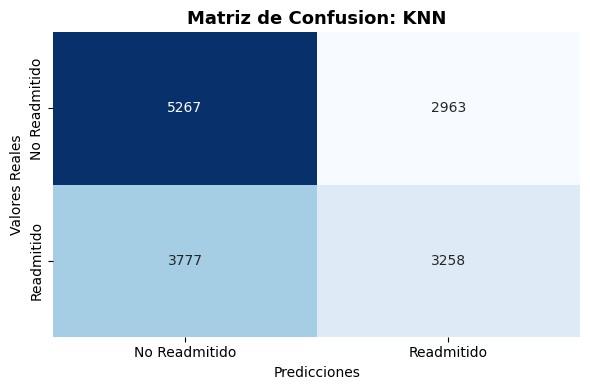

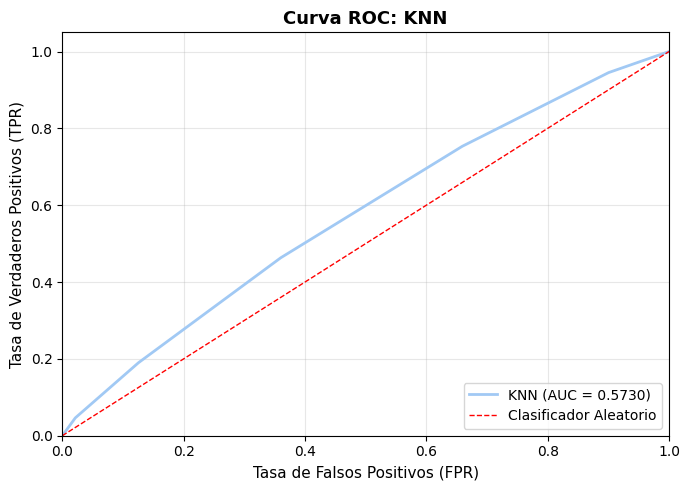


Interpretacion:
  - El modelo muestra desempeno moderado en ambas metricas
  - F1-score bajo (0.4916) indica limitaciones en la prediccion
  - AUC bajo (0.5730): poca capacidad de discriminacion


{'Modelo': 'KNN',
 'Accuracy': 0.5585,
 'Precision': 0.5237,
 'Recall': 0.4631,
 'F1-score': 0.4916,
 'AUC': np.float64(0.573),
 'TN': 5267,
 'FP': 2963,
 'FN': 3777,
 'TP': 3258}

In [30]:
# KNN con Ball Trees (optimizado para alta dimensionalidad)
knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1)
evaluar_modelo_completo("KNN", knn_model, X_train_array, y_train, X_test_array, y_test)

### 4.2. Naive Bayes


EVALUANDO: Naive Bayes

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6012
  Precision: 0.5906
  Recall:    0.4388
  F1-score:  0.5035
  AUC:       0.6255

Matriz de Confusion:
  TN=6090  FP=2140
  FN=3948  TP=3087
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6012
  Precision: 0.5906
  Recall:    0.4388
  F1-score:  0.5035
  AUC:       0.6255

Matriz de Confusion:
  TN=6090  FP=2140
  FN=3948  TP=3087


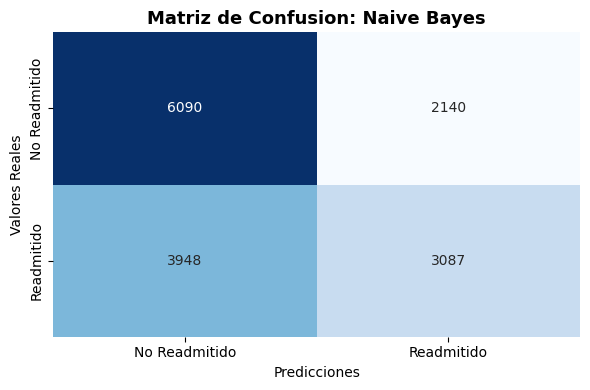

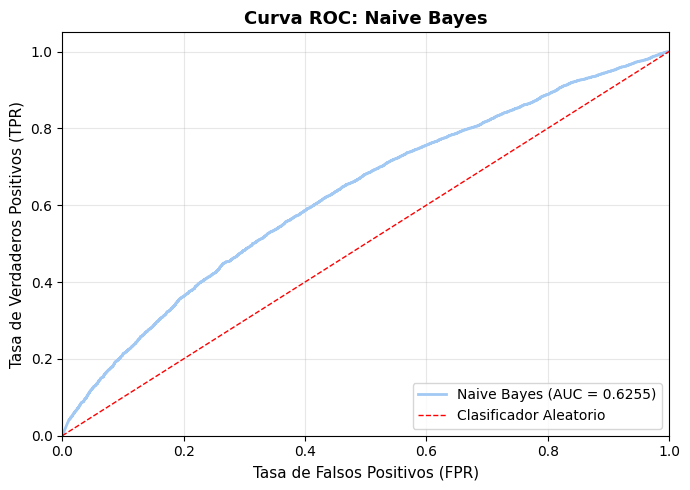


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5035) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6255): discriminacion limitada


{'Modelo': 'Naive Bayes',
 'Accuracy': 0.6012,
 'Precision': 0.5906,
 'Recall': 0.4388,
 'F1-score': 0.5035,
 'AUC': np.float64(0.6255),
 'TN': 6090,
 'FP': 2140,
 'FN': 3948,
 'TP': 3087}

In [31]:
# Naive Bayes (GaussianNB)
nb_model = GaussianNB()
evaluar_modelo_completo("Naive Bayes", nb_model, X_train_array, y_train, X_test_array, y_test)

### 4.3. Ridge Classifier


EVALUANDO: Ridge

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6271
  Precision: 0.6403
  Recall:    0.4357
  F1-score:  0.5185
  AUC:       0.6714

Matriz de Confusion:
  TN=6508  FP=1722
  FN=3970  TP=3065
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6271
  Precision: 0.6403
  Recall:    0.4357
  F1-score:  0.5185
  AUC:       0.6714

Matriz de Confusion:
  TN=6508  FP=1722
  FN=3970  TP=3065


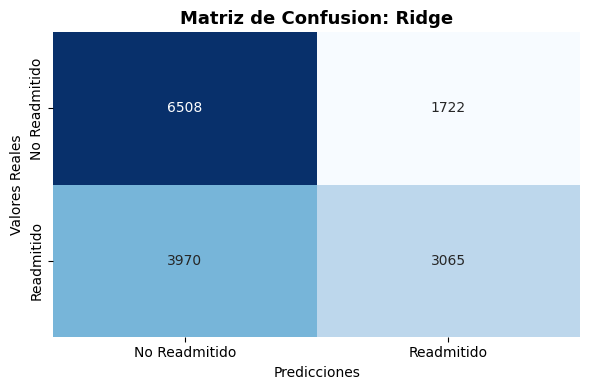

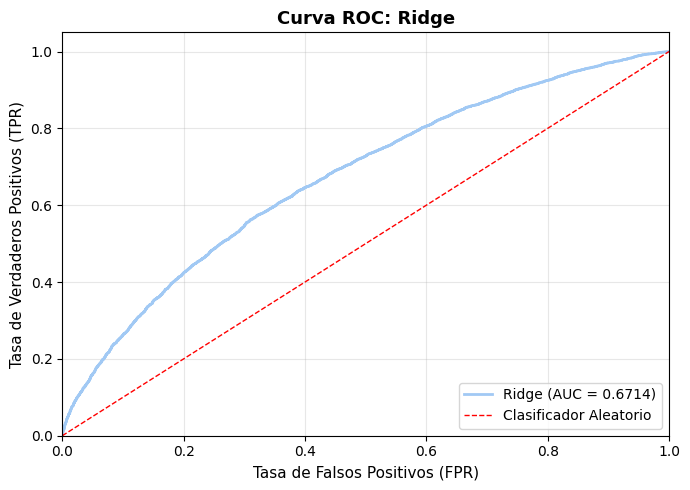


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5185) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6714): discriminacion limitada


{'Modelo': 'Ridge',
 'Accuracy': 0.6271,
 'Precision': 0.6403,
 'Recall': 0.4357,
 'F1-score': 0.5185,
 'AUC': np.float64(0.6714),
 'TN': 6508,
 'FP': 1722,
 'FN': 3970,
 'TP': 3065}

In [32]:
# Ridge con solver 'saga' (optimizado)
ridge_model = RidgeClassifier(alpha=1.0, solver='saga', random_state=42)
evaluar_modelo_completo("Ridge", ridge_model, X_train_array, y_train, X_test_array, y_test)

### 4.4. Lasso (Regresion Logistica L1)


EVALUANDO: Lasso

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6298
  Precision: 0.6432
  Recall:    0.4418
  F1-score:  0.5238
  AUC:       0.6740

Matriz de Confusion:
  TN=6506  FP=1724
  FN=3927  TP=3108
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6298
  Precision: 0.6432
  Recall:    0.4418
  F1-score:  0.5238
  AUC:       0.6740

Matriz de Confusion:
  TN=6506  FP=1724
  FN=3927  TP=3108


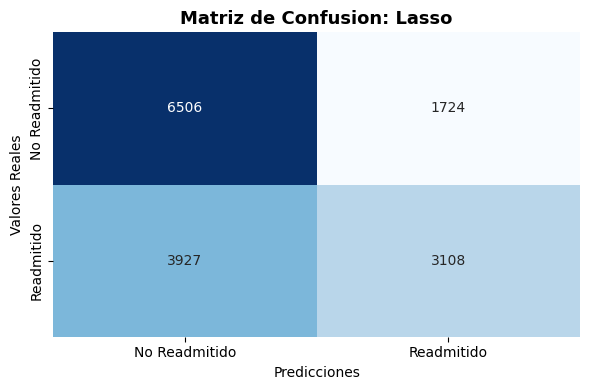

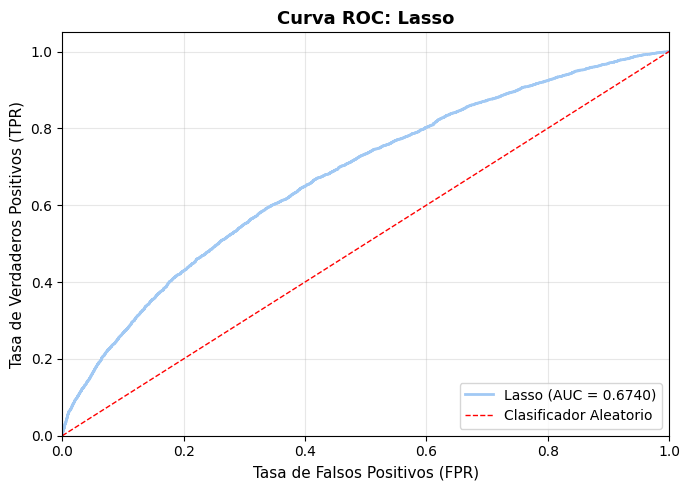


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5238) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6740): discriminacion limitada


{'Modelo': 'Lasso',
 'Accuracy': 0.6298,
 'Precision': 0.6432,
 'Recall': 0.4418,
 'F1-score': 0.5238,
 'AUC': np.float64(0.674),
 'TN': 6506,
 'FP': 1724,
 'FN': 3927,
 'TP': 3108}

In [33]:
# Lasso con solver 'saga' (optimizado)
lasso_model = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, n_jobs=-1, random_state=42)
evaluar_modelo_completo("Lasso", lasso_model, X_train_array, y_train, X_test_array, y_test)

### 4.5. Regresion Logistica L2 (Ridge)


EVALUANDO: LogReg L2

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6298
  Precision: 0.6431
  Recall:    0.4421
  F1-score:  0.5240
  AUC:       0.6740

Matriz de Confusion:
  TN=6504  FP=1726
  FN=3925  TP=3110
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6298
  Precision: 0.6431
  Recall:    0.4421
  F1-score:  0.5240
  AUC:       0.6740

Matriz de Confusion:
  TN=6504  FP=1726
  FN=3925  TP=3110


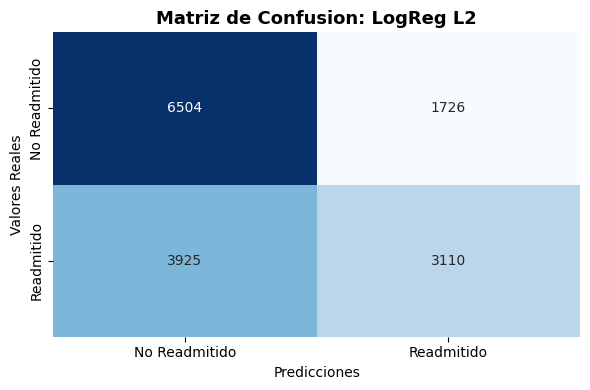

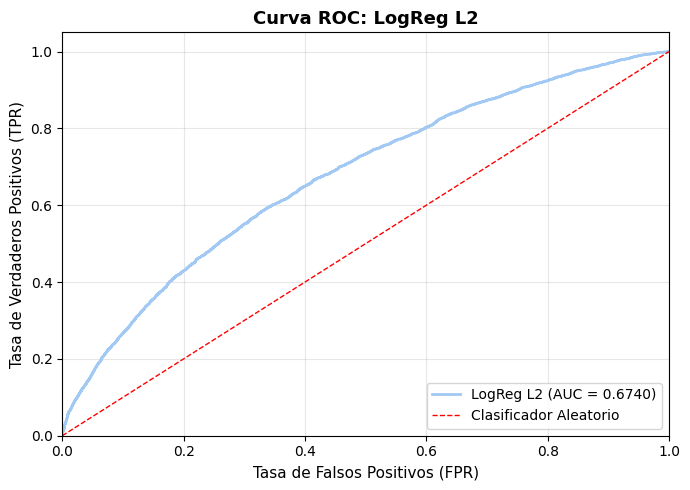


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5240) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6740): discriminacion limitada


{'Modelo': 'LogReg L2',
 'Accuracy': 0.6298,
 'Precision': 0.6431,
 'Recall': 0.4421,
 'F1-score': 0.524,
 'AUC': np.float64(0.674),
 'TN': 6504,
 'FP': 1726,
 'FN': 3925,
 'TP': 3110}

In [34]:
# Regresion Logistica L2
logreg_l2_model = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, n_jobs=-1, random_state=42)
evaluar_modelo_completo("LogReg L2", logreg_l2_model, X_train_array, y_train, X_test_array, y_test)

### 4.6. Regresion Logistica L1 (Lasso alternativo)


EVALUANDO: LogReg L1

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6297
  Precision: 0.6429
  Recall:    0.4422
  F1-score:  0.5240
  AUC:       0.6740

Matriz de Confusion:
  TN=6502  FP=1728
  FN=3924  TP=3111
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6297
  Precision: 0.6429
  Recall:    0.4422
  F1-score:  0.5240
  AUC:       0.6740

Matriz de Confusion:
  TN=6502  FP=1728
  FN=3924  TP=3111


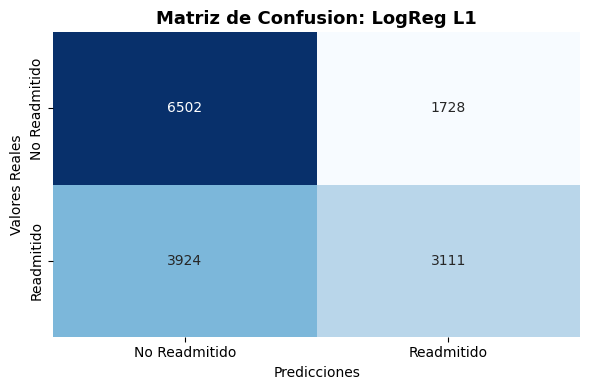

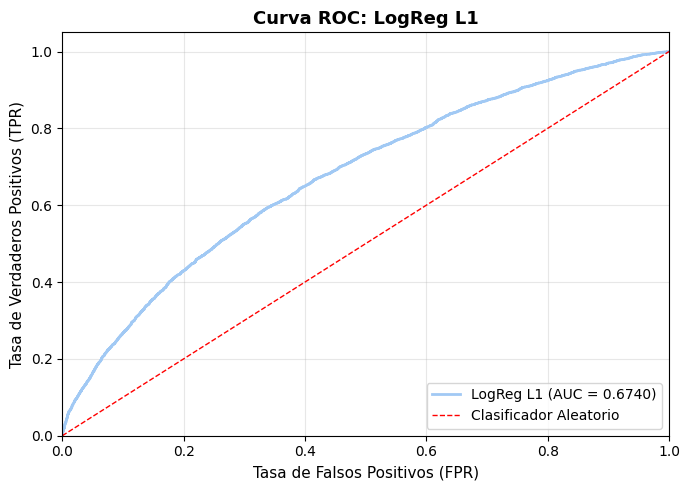


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5240) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6740): discriminacion limitada


{'Modelo': 'LogReg L1',
 'Accuracy': 0.6297,
 'Precision': 0.6429,
 'Recall': 0.4422,
 'F1-score': 0.524,
 'AUC': np.float64(0.674),
 'TN': 6502,
 'FP': 1728,
 'FN': 3924,
 'TP': 3111}

In [35]:
# Regresion Logistica L1 con solver liblinear
logreg_l1_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
evaluar_modelo_completo("LogReg L1", logreg_l1_model, X_train_array, y_train, X_test_array, y_test)

### 4.7. Arbol de Decision


EVALUANDO: Arbol Decision

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6203
  Precision: 0.6204
  Recall:    0.4537
  F1-score:  0.5241
  AUC:       0.6557

Matriz de Confusion:
  TN=6277  FP=1953
  FN=3843  TP=3192
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6203
  Precision: 0.6204
  Recall:    0.4537
  F1-score:  0.5241
  AUC:       0.6557

Matriz de Confusion:
  TN=6277  FP=1953
  FN=3843  TP=3192


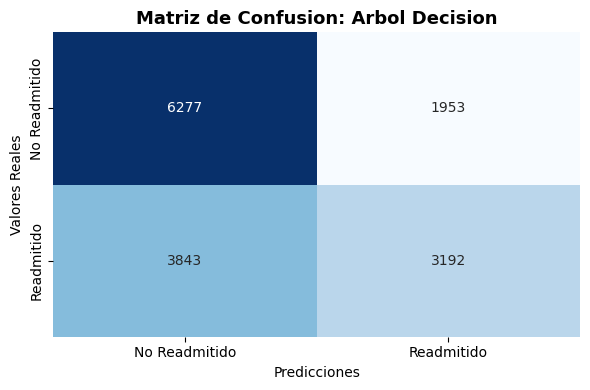

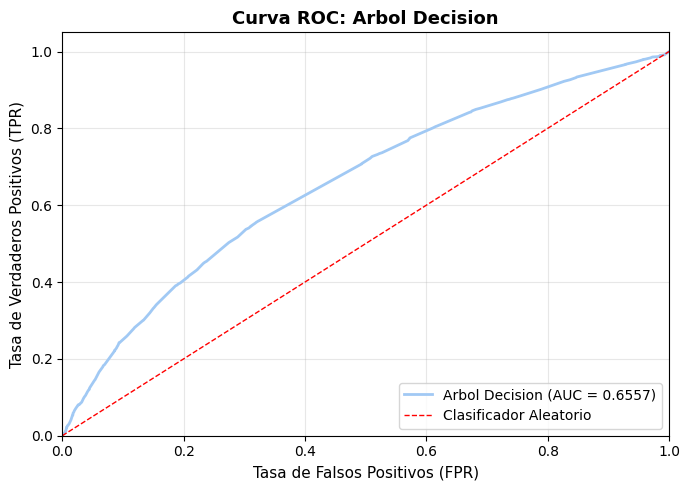


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5241) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6557): discriminacion limitada


{'Modelo': 'Arbol Decision',
 'Accuracy': 0.6203,
 'Precision': 0.6204,
 'Recall': 0.4537,
 'F1-score': 0.5241,
 'AUC': np.float64(0.6557),
 'TN': 6277,
 'FP': 1953,
 'FN': 3843,
 'TP': 3192}

In [36]:
# Arbol de Decision
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
evaluar_modelo_completo("Arbol Decision", dt_model, X_train_array, y_train, X_test_array, y_test)

### 4.8. Random Forest


EVALUANDO: Random Forest

Entrenando modelo...
Modelo entrenado correctamente
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6292
  Precision: 0.6194
  Recall:    0.5066
  F1-score:  0.5574
  AUC:       0.6720

Matriz de Confusion:
  TN=6040  FP=2190
  FN=3471  TP=3564

Metricas calculadas:
  Accuracy:  0.6292
  Precision: 0.6194
  Recall:    0.5066
  F1-score:  0.5574
  AUC:       0.6720

Matriz de Confusion:
  TN=6040  FP=2190
  FN=3471  TP=3564


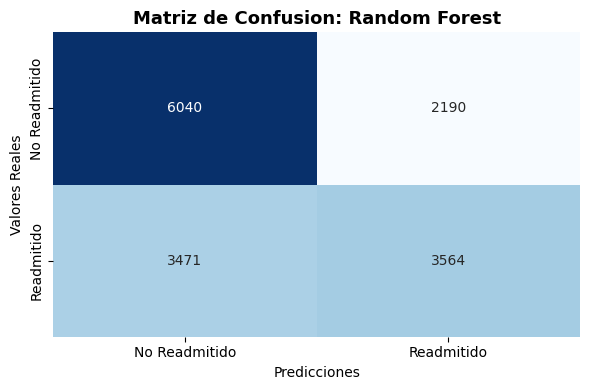

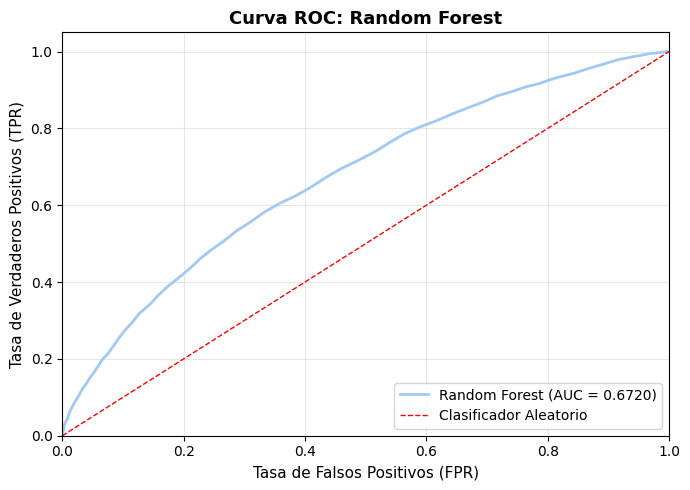


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5574) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6720): discriminacion limitada


{'Modelo': 'Random Forest',
 'Accuracy': 0.6292,
 'Precision': 0.6194,
 'Recall': 0.5066,
 'F1-score': 0.5574,
 'AUC': np.float64(0.672),
 'TN': 6040,
 'FP': 2190,
 'FN': 3471,
 'TP': 3564}

In [37]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluar_modelo_completo("Random Forest", rf_model, X_train_array, y_train, X_test_array, y_test)

### 4.9. XGBoost


EVALUANDO: XGBoost

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6341
  Precision: 0.6229
  Recall:    0.5224
  F1-score:  0.5682
  AUC:       0.6787

Matriz de Confusion:
  TN=6005  FP=2225
  FN=3360  TP=3675
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6341
  Precision: 0.6229
  Recall:    0.5224
  F1-score:  0.5682
  AUC:       0.6787

Matriz de Confusion:
  TN=6005  FP=2225
  FN=3360  TP=3675


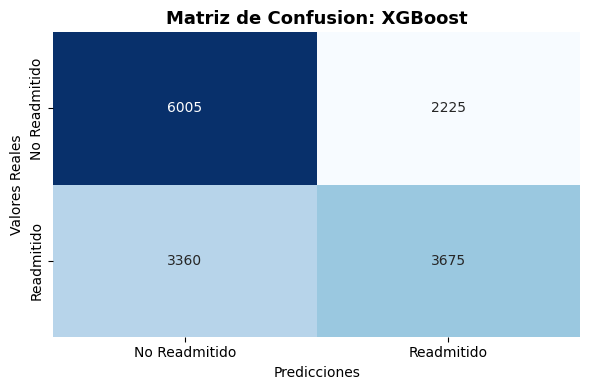

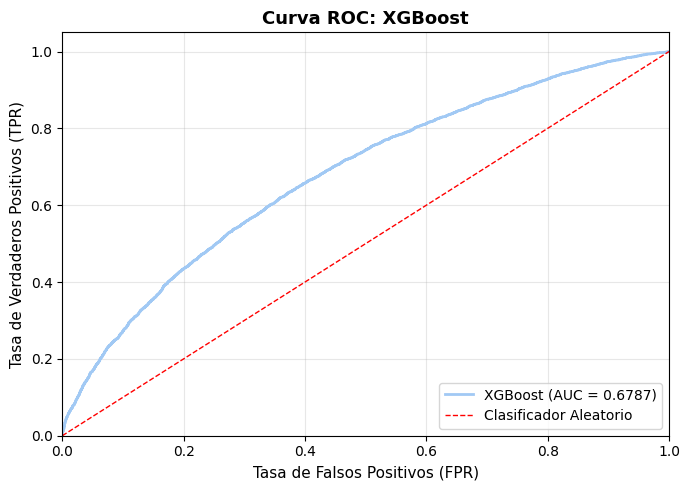


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5682) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6787): discriminacion limitada


{'Modelo': 'XGBoost',
 'Accuracy': 0.6341,
 'Precision': 0.6229,
 'Recall': 0.5224,
 'F1-score': 0.5682,
 'AUC': np.float64(0.6787),
 'TN': 6005,
 'FP': 2225,
 'FN': 3360,
 'TP': 3675}

In [38]:
# XGBoost con tree_method='hist' (optimizado)
xgb_model = XGBClassifier(
    eval_metric='logloss',
    enable_categorical=False,
    tree_method='hist',
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)
evaluar_modelo_completo("XGBoost", xgb_model, X_train_array, y_train, X_test_array, y_test)

### 4.10. SVM Lineal


EVALUANDO: SVM Lineal

Entrenando modelo...
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6290
  Precision: 0.6444
  Recall:    0.4351
  F1-score:  0.5195
  AUC:       0.6732

Matriz de Confusion:
  TN=6541  FP=1689
  FN=3974  TP=3061
Modelo entrenado correctamente

Metricas calculadas:
  Accuracy:  0.6290
  Precision: 0.6444
  Recall:    0.4351
  F1-score:  0.5195
  AUC:       0.6732

Matriz de Confusion:
  TN=6541  FP=1689
  FN=3974  TP=3061


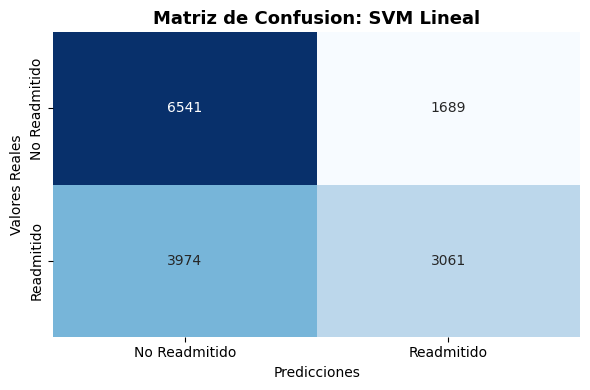

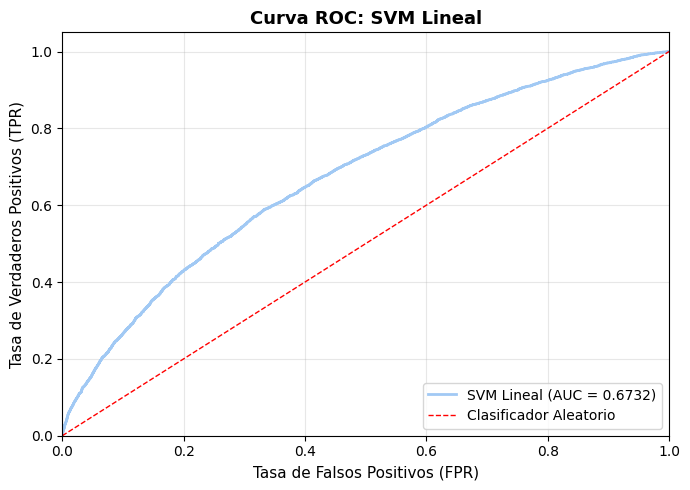


Interpretacion:
  - El modelo es conservador: prioriza precision sobre recall
  - Predice readmision solo cuando tiene alta confianza
  - F1-score moderado (0.5195) sugiere capacidad predictiva aceptable
  - AUC moderado (0.6732): discriminacion limitada


{'Modelo': 'SVM Lineal',
 'Accuracy': 0.629,
 'Precision': 0.6444,
 'Recall': 0.4351,
 'F1-score': 0.5195,
 'AUC': np.float64(0.6732),
 'TN': 6541,
 'FP': 1689,
 'FN': 3974,
 'TP': 3061}

In [39]:
# SVM Lineal (LinearSVC optimizado)
svm_model = LinearSVC(random_state=42, dual='auto', max_iter=1000)
evaluar_modelo_completo("SVM Lineal", svm_model, X_train_array, y_train, X_test_array, y_test)

## Tabla Resumen de Metricas

A continuacion presentamos la tabla consolidada con todas las metricas de evaluacion.

In [ ]:
# =========================================
# 5. Tabla resumen de metricas
# =========================================

# Crear DataFrame con todos los resultados
df_metricas = pd.DataFrame(resultados_evaluacion)

print("\n" + "="*100)
print(" "*30 + "TABLA DE METRICAS - CLASIFICACION")
print("="*100 + "\n")

# Mostrar tabla ordenada por F1-score
df_display = df_metricas[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']].copy()
df_display = df_display.sort_values(by='F1-score', ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

print(df_display.to_string(index=False))

print("\n" + "="*100)

# Guardar resultados
df_metricas.to_csv('../data/processed/evaluacion_metricas.csv', index=False)
print("\nResultados guardados en '../data/processed/evaluacion_metricas.csv'")


                              TABLA DE METRICAS - CLASIFICACION

        Modelo  Accuracy  Precision  Recall  F1-score    AUC
       XGBoost    0.6341     0.6229  0.5224    0.5682 0.6787
 Random Forest    0.6292     0.6194  0.5066    0.5574 0.6720
Arbol Decision    0.6203     0.6204  0.4537    0.5241 0.6557
     LogReg L1    0.6297     0.6429  0.4422    0.5240 0.6740
     LogReg L2    0.6298     0.6431  0.4421    0.5240 0.6740
         Lasso    0.6298     0.6432  0.4418    0.5238 0.6740
    SVM Lineal    0.6290     0.6444  0.4351    0.5195 0.6732
         Ridge    0.6271     0.6403  0.4357    0.5185 0.6714
   Naive Bayes    0.6012     0.5906  0.4388    0.5035 0.6255
           KNN    0.5585     0.5237  0.4631    0.4916 0.5730


Resultados guardados en 'data/processed/evaluacion_metricas.csv'


## Comparacion Visual de Metricas

Visualizamos las metricas clave para facilitar la comparacion entre modelos.

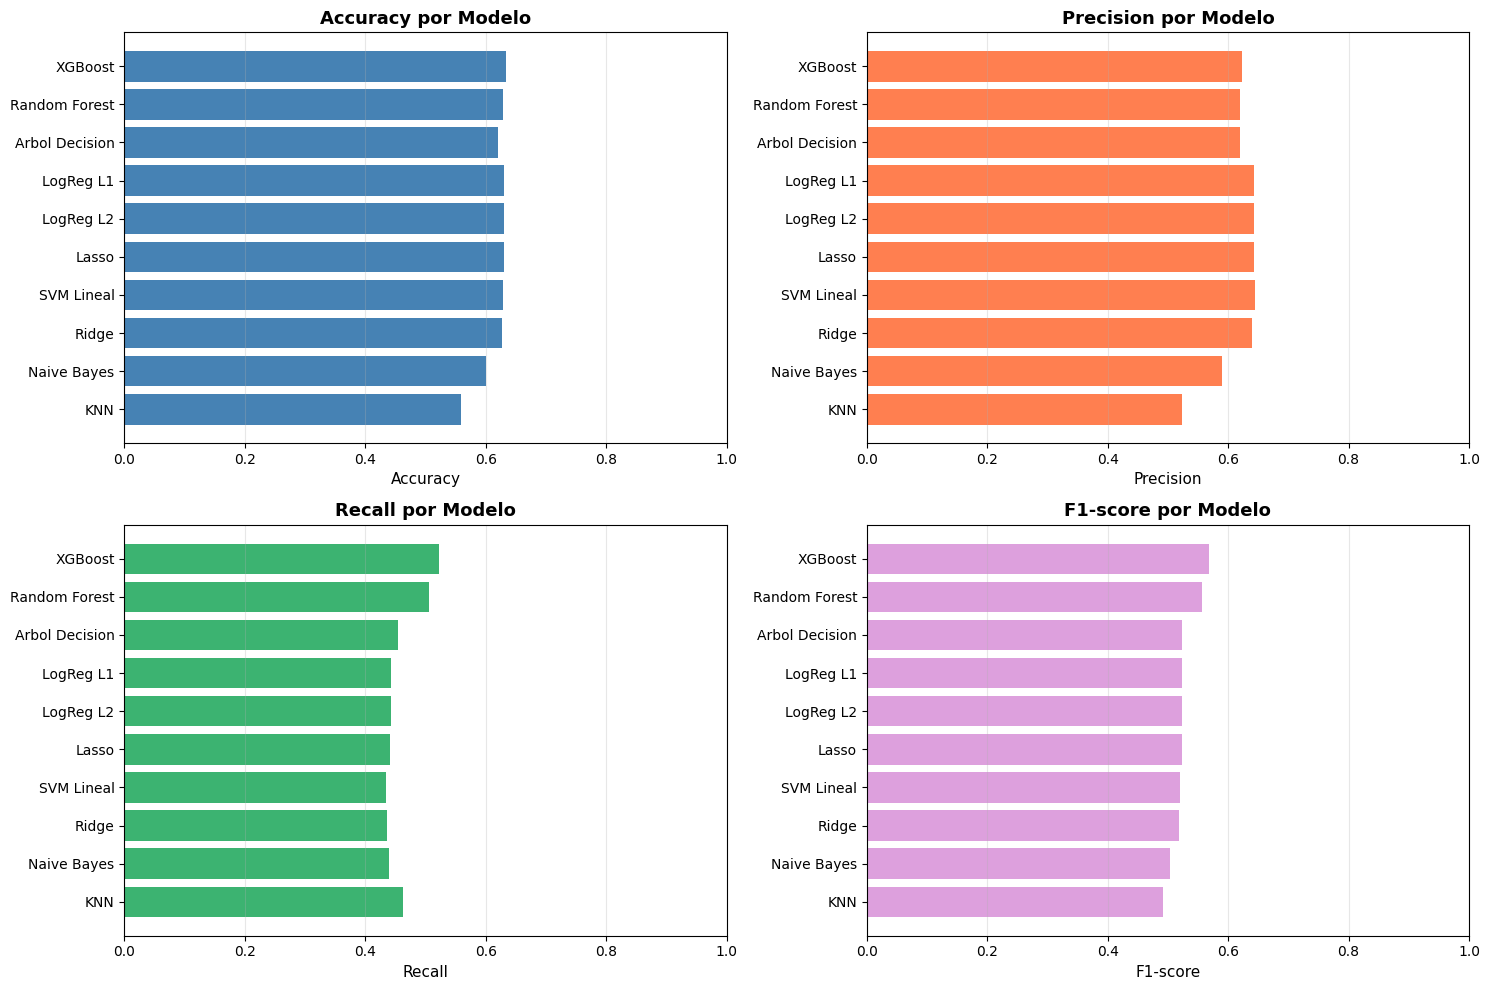

Visualizacion completada


In [41]:
# =========================================
# 6. Visualizacion comparativa de metricas
# =========================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Ordenar por F1-score para todas las visualizaciones
df_sorted = df_metricas.sort_values(by='F1-score', ascending=True)

# 1. Accuracy
axes[0, 0].barh(df_sorted['Modelo'], df_sorted['Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Accuracy por Modelo', fontsize=13, fontweight='bold')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Precision
axes[0, 1].barh(df_sorted['Modelo'], df_sorted['Precision'], color='coral')
axes[0, 1].set_xlabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision por Modelo', fontsize=13, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Recall
axes[1, 0].barh(df_sorted['Modelo'], df_sorted['Recall'], color='mediumseagreen')
axes[1, 0].set_xlabel('Recall', fontsize=11)
axes[1, 0].set_title('Recall por Modelo', fontsize=13, fontweight='bold')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. F1-score
axes[1, 1].barh(df_sorted['Modelo'], df_sorted['F1-score'], color='plum')
axes[1, 1].set_xlabel('F1-score', fontsize=11)
axes[1, 1].set_title('F1-score por Modelo', fontsize=13, fontweight='bold')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizacion completada")

## Justificacion de la Metrica Principal

#### **Análisis de Métricas de Evaluación**

Para seleccionar la métrica más adecuada, nuestro equipo ha evaluado las siguientes opciones:

-   **Accuracy (Exactitud):**
    -   *Definición:* Mide el porcentaje total de predicciones correctas.
    -   *Limitación:* Puede ser una métrica engañosa en conjuntos de datos con desbalance de clases, como es nuestro caso, donde el número de pacientes no readmitidos es significativamente mayor. Por esta razón, no la consideramos una métrica principal.

-   **Precision (Precisión):**
    -   *Definición:* De los pacientes que nuestro modelo predice como "readmitidos", ¿qué porcentaje realmente lo fue? (`TP / (TP + FP)`).
    -   *Relevancia:* Es crucial cuando el coste de los **falsos positivos** es alto. Una alta precisión significa que nuestras alertas de riesgo son fiables, minimizando intervenciones innecesarias en pacientes que no lo necesitan.

-   **Recall (Sensibilidad):**
    -   *Definición:* De todos los pacientes que realmente fueron readmitidos, ¿qué porcentaje fuimos capaces de identificar? (`TP / (TP + FN)`).
    -   *Relevancia:* Es fundamental cuando el coste de los **falsos negativos** es alto. Un alto recall asegura que detectamos a la mayoría de los pacientes en riesgo, lo que permite aplicar intervenciones preventivas de manera efectiva.

-   **F1-Score:**
    -   *Definición:* Es la media armónica entre Precision y Recall (`2 * (Precision * Recall) / (Precision + Recall)`).
    -   *Relevancia:* Es ideal para escenarios donde se necesita un equilibrio entre minimizar falsos positivos (Precision) y minimizar falsos negativos (Recall). Dado nuestro contexto clínico, este balance es exactamente lo que buscamos.

-   **AUC (Área Bajo la Curva ROC):**
    -   *Definición:* Mide la capacidad general del modelo para discriminar entre la clase positiva y la negativa, independientemente del umbral de clasificación.
    -   *Relevancia:* Es muy útil para comparar el poder discriminatorio intrínseco de diferentes modelos.

#### **Métrica Principal Seleccionada: F1-Score**

Tras un análisis detallado, **el equipo ha seleccionado el F1-Score como la métrica principal** para la optimización y selección del modelo final.

**Justificación:**

1.  **Equilibrio entre Consecuencias Clínicas:** En el ámbito médico, tanto los falsos positivos como los falsos negativos tienen implicaciones significativas.
    -   **Falsos Negativos (Bajo Recall):** No identificar a un paciente que será readmitido implica perder una oportunidad crítica de intervención preventiva.
    -   **Falsos Positivos (Baja Precisión):** Alertar innecesariamente sobre un paciente implica un uso ineficiente de recursos y puede generar preocupación innecesaria.
    -   El F1-Score penaliza a los modelos que se decantan excesivamente por uno de estos extremos, promoviendo un equilibrio pragmático.

2.  **Robustez ante el Desbalance de Clases:** A diferencia del Accuracy, el F1-Score es una métrica mucho más informativa en datasets desbalanceados, ya que se centra exclusivamente en el rendimiento sobre la clase minoritaria (pacientes readmitidos), que es la de mayor interés.

3.  **Interpretabilidad y Comparabilidad:** Un F1-Score alto indica que el modelo es eficaz tanto en la identificación de casos positivos como en la fiabilidad de sus predicciones. Esto facilita la comparación directa y justa entre diferentes arquitecturas de modelos.

#### **Métricas Secundarias**

Aunque el F1-Score es nuestra guía principal, complementamos nuestra evaluación con:
-   **AUC:** para medir la capacidad de discriminación general.
-   **Recall:** para asegurar que nuestra tasa de detección de pacientes en riesgo es aceptable.
-   **Precision:** para controlar el volumen de falsas alarmas.

#### **Conclusión de la Evaluación**

Utilizamos el F1-Score como el criterio primario para la selección del modelo, mientras que el análisis de AUC, Recall y Precision nos proporciona una visión integral de su comportamiento, asegurando que el modelo seleccionado no solo es estadísticamente robusto, sino también clínicamente útil.

---

### **Resultados del Mejor Modelo Seleccionado**

Tras la fase de experimentación y optimización, el modelo que ha demostrado el mejor rendimiento según nuestra métrica principal es:

-   **Modelo:** XGBoost
-   **F1-Score:** `0.5682`
-   **Precision:** `0.6229`
-   **Recall:** `0.5224`
-   **AUC:** `0.6787`